In [19]:
import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
def build_database():
  print("Downloading raw real-world IBM Telco Churn dataset...")
  raw_url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
  raw_df = pd.read_csv(raw_url)

  print("Sharding columns into optimized relational database...")

  demographics_df = raw_df[['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents']].copy()
  services_df = raw_df[['customerID', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']].copy()
  account_df = raw_df[['customerID', 'tenure', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']].copy()

  conn = sqlite3.connect('enterprise_telecom.db')
  cursor = conn.cursor()

  cursor.execute("PRAGMA foreign_keys = ON;")

  print("🗄️ Initializing tables inside 'enterprise_telecom.db'...")

  cursor.execute("DROP TABLE IF EXISTS billing_accounts;")
  cursor.execute("DROP TABLE IF EXISTS services;")
  cursor.execute("DROP TABLE IF EXISTS demographics;")

  cursor.execute('''
      CREATE TABLE demographics (
          customerID TEXT PRIMARY KEY,
          gender TEXT,
          SeniorCitizen INTEGER,
          Partner TEXT,
          Dependents TEXT
      )''')

  cursor.execute('''
      CREATE TABLE services (
          customerID TEXT PRIMARY KEY,
          PhoneService TEXT,
          MultipleLines TEXT,
          InternetService TEXT,
          OnlineSecurity TEXT,
          OnlineBackup TEXT,
          DeviceProtection TEXT,
          TechSupport TEXT,
          StreamingTV TEXT,
          StreamingMovies TEXT,
          FOREIGN KEY (customerID) REFERENCES demographics(customerID)
      )''')

  cursor.execute('''
      CREATE TABLE billing_accounts (
          customerID TEXT PRIMARY KEY,
          tenure INTEGER,
          Contract TEXT,
          PaperlessBilling TEXT,
          PaymentMethod TEXT,
          MonthlyCharges REAL,
          TotalCharges TEXT,
          Churn TEXT,
          FOREIGN KEY (customerID) REFERENCES demographics(customerID)
      )''')

  demographics_df.to_sql('demographics', conn, if_exists='append', index=False)
  services_df.to_sql('services', conn, if_exists='append', index=False)
  account_df.to_sql('billing_accounts', conn, if_exists='append', index=False)

  cursor.execute("CREATE INDEX IF NOT EXISTS idx_cust_billing ON billing_accounts(customerID);")

  conn.commit()
  conn.close()

build_database()

Sharding columns into optimized relational database...
🗄️ Initializing tables inside 'enterprise_telecom.db'...


In [3]:
def extract_and_clean_data():
  conn = sqlite3.connect('enterprise_telecom.db')

  sql_query = """
  SELECT
        d.customerID, d.gender, d.SeniorCitizen, d.Partner, d.Dependents,
        s.PhoneService, s.MultipleLines, s.InternetService, s.OnlineSecurity,
        s.OnlineBackup, s.DeviceProtection, s.TechSupport, s.StreamingTV, s.StreamingMovies,
        b.tenure, b.Contract, b.PaperlessBilling, b.PaymentMethod, b.MonthlyCharges, b.TotalCharges, b.Churn
    FROM demographics d
    INNER JOIN services s ON d.customerID = s.customerID
    INNER JOIN billing_accounts b ON d.customerID = b.customerID
  """

  df = pd.read_sql_query(sql_query, conn)
  conn.close()

  print(f"Raw joined dataset pulled from SQL. Shape: {df.shape}")

  print(f"Before cleaning: 'TotalCharges' column data type is: {df['TotalCharges'].dtype}")

  df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
  df['TotalCharges'] = df['TotalCharges'].astype(float)

  missing_count = df['TotalCharges'].isnull().sum()
  print(f"Uncovered {missing_count} hidden missing values in 'TotalCharges'!")

  median_value = df['TotalCharges'].median()
  df['TotalCharges'].fillna(median_value, inplace=True)

  print(f"After cleaning: 'TotalCharges' column data type is: {df['TotalCharges'].dtype}")
  print("Missing data successfully handled!")

  print("\n--- Summary Statistics for Continuous Features ---")
  print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().T)

  return df

# Run the extraction and cleaning function
cleaned_df = extract_and_clean_data()

Raw joined dataset pulled from SQL. Shape: (7043, 21)
Before cleaning: 'TotalCharges' column data type is: object
Uncovered 11 hidden missing values in 'TotalCharges'!
After cleaning: 'TotalCharges' column data type is: float64
Missing data successfully handled!

--- Summary Statistics for Continuous Features ---
                 count         mean          std    min      25%       50%  \
tenure          7043.0    32.371149    24.559481   0.00    9.000    29.000   
MonthlyCharges  7043.0    64.761692    30.090047  18.25   35.500    70.350   
TotalCharges    7043.0  2281.916928  2265.270398  18.80  402.225  1397.475   

                    75%      max  
tenure            55.00    72.00  
MonthlyCharges    89.85   118.75  
TotalCharges    3786.60  8684.80  


/tmp/ipykernel_1040/924231461.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(median_value, inplace=True)


In [5]:
cleaned_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,No,No phone service,DSL,No,Yes,...,No,No,No,1,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,Yes,No,DSL,Yes,No,...,No,No,No,34,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,Yes,No,DSL,Yes,Yes,...,No,No,No,2,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,No,No phone service,DSL,Yes,No,...,Yes,No,No,45,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,Yes,No,Fiber optic,No,No,...,No,No,No,2,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
cleaned_df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [7]:
cleaned_df.groupby('Churn')['tenure'].mean()

,tenure
Churn,
No,37.569965
Yes,17.979133


/tmp/ipykernel_1040/780503461.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=cleaned_df, ax=axes[0], palette='coolwarm')
/tmp/ipykernel_1040/780503461.py:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=cleaned_df, x='tenure', hue='Churn', shade=True, ax=axes[1], palette='coolwarm')


Text(0.5, 0, 'Months Subscribed (Tenure)')

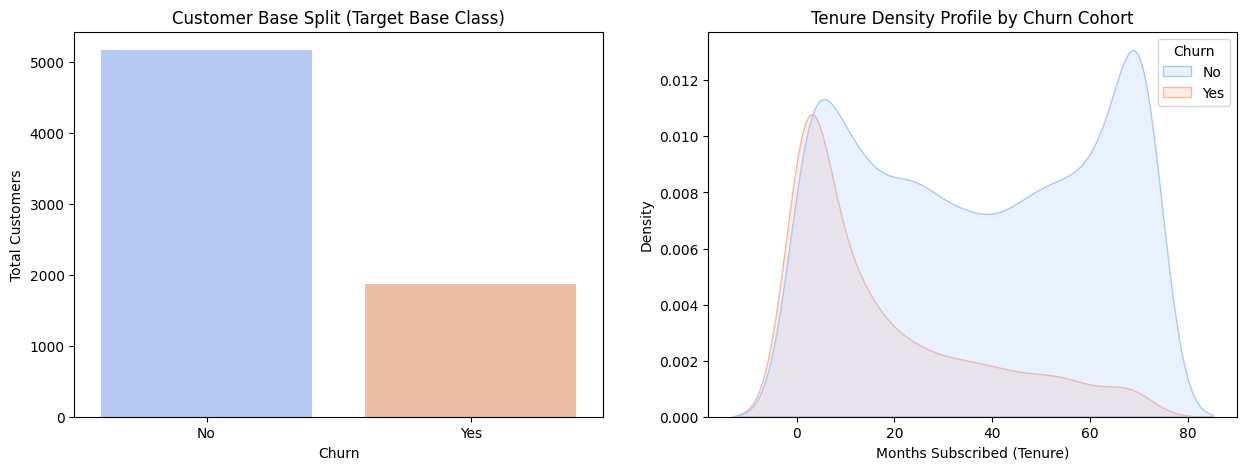

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Chart A: Target Imbalance Visualization
sns.countplot(x='Churn', data=cleaned_df, ax=axes[0], palette='coolwarm')
axes[0].set_title('Customer Base Split (Target Base Class)')
axes[0].set_ylabel('Total Customers')

# Chart B: Distribution Analysis (Kernel Density Estimate)
# This shows exactly where the high density of churn sits along the timeline
sns.kdeplot(data=cleaned_df, x='tenure', hue='Churn', shade=True, ax=axes[1], palette='coolwarm')
axes[1].set_title('Tenure Density Profile by Churn Cohort')
axes[1].set_xlabel('Months Subscribed (Tenure)')

In [12]:
cleaned_df.groupby('Churn')['MonthlyCharges'].mean()

,MonthlyCharges
Churn,
No,61.265124
Yes,74.441332


<Axes: xlabel='MonthlyCharges', ylabel='Density'>

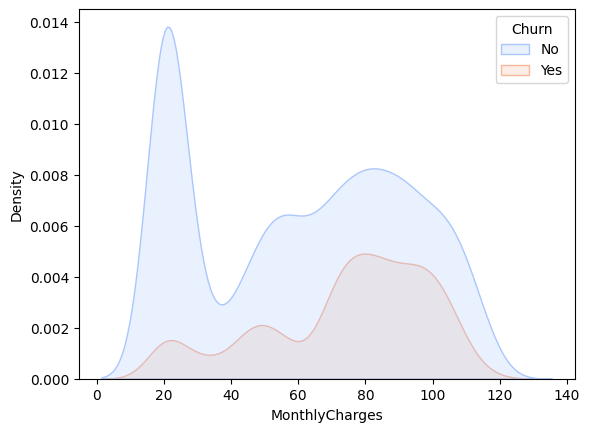

In [18]:
sns.kdeplot(data=cleaned_df, x='MonthlyCharges', hue='Churn', fill=True, palette='coolwarm')

In [14]:
cleaned_df[cleaned_df['Churn'] == 'Yes']['InternetService'].value_counts(normalize=True) * 100

,proportion
InternetService,
Fiber optic,69.395399
DSL,24.558587
No,6.046014


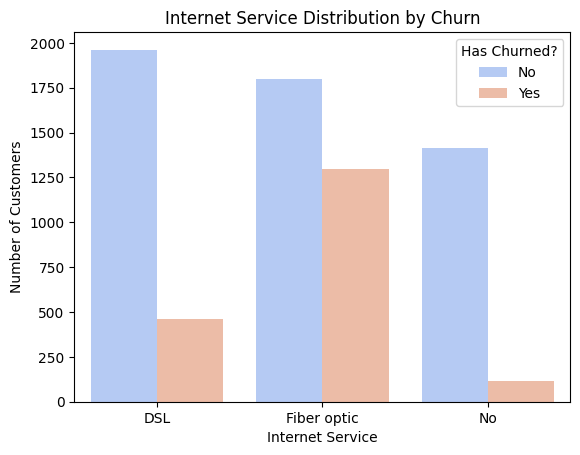

In [15]:
sns.countplot(data=cleaned_df, x='InternetService', hue='Churn', palette='coolwarm')
plt.title('Internet Service Distribution by Churn')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.legend(title='Has Churned?')
plt.show()

In [20]:
y = cleaned_df['Churn'].map({'Yes': 1, 'No': 0})
X = cleaned_df.drop(['customerID', 'Churn'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# 1. Continuous numerical features that need scaling
numeric_features = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

# 2. Categorical features (strings/text) that need one-hot encoding
categorical_features = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Pipeline architecture assembled successfully!")

Pipeline architecture assembled successfully!


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.pipeline import Pipeline

models = {
    "Logistic Regression": Pipeline(steps=[('preprocessor', preprocessor),
                                           ('classifier', LogisticRegression(max_iter=1000, random_state=42))]),

    "Random Forest": Pipeline(steps=[('preprocessor', preprocessor),
                                     ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))]),

    "XGBoost": Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', xgb.XGBClassifier(random_state=42, eval_metric='logloss'))])
}

print("Models are loaded and armed for the bake-off!")

Models are loaded and armed for the bake-off!


In [27]:
from sklearn.model_selection import cross_val_score

print("5-Fold Cross-Validation F1-Scores")

for name, pipeline in models.items():
  scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1')
  mean_f1 = np.mean(scores)
  print(f"{name}: {mean_f1 * 100:.2f}")

5-Fold Cross-Validation F1-Scores
Logistic Regression: 59.06
Random Forest: 53.99
XGBoost: 55.67


In [31]:
from sklearn.metrics import classification_report

winning_model = models["Logistic Regression"]

winning_model.fit(X_train, y_train)

y_pred = winning_model.predict(X_test)

print("Final Evaluation on Unseen Test Data")
print(classification_report(y_test, y_pred))

Final Evaluation on Unseen Test Data
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [32]:
import pickle

# Save the full trained workflow (preprocessor + model) to disk
with open('winning_churn_pipeline.pkl', 'wb') as file:
    pickle.dump(winning_model, file)

print("Winning pipeline successfully compiled and saved to disk as 'winning_churn_pipeline.pkl'!")

Winning pipeline successfully compiled and saved to disk as 'winning_churn_pipeline.pkl'!


In [33]:
%%writefile app.py
from fastapi import FastAPI
from pydantic import BaseModel
import pickle
import pandas as pd

# 1. Initialize the FastAPI framework instance
app = FastAPI(title="Enterprise Customer Retention Engine", version="1.0")

# 2. Load the compiled machine learning pipeline into memory once when the server boots
with open('winning_churn_pipeline.pkl', 'rb') as file:
    pipeline = pickle.load(file)

# 3. Define the structural data schema expected by the endpoint
class CustomerPayload(BaseModel):
    gender: str
    SeniorCitizen: int
    Partner: str
    Dependents: str
    PhoneService: str
    MultipleLines: str
    InternetService: str
    OnlineSecurity: str
    OnlineBackup: str
    DeviceProtection: str
    TechSupport: str
    StreamingTV: str
    StreamingMovies: str
    tenure: int
    Contract: str
    PaperlessBilling: str
    PaymentMethod: str
    MonthlyCharges: float
    TotalCharges: float

# 4. Create the operational POST endpoint for predictions
@app.post("/predict")
def predict_customer_churn(data: CustomerPayload):
    # Convert the incoming structured JSON payload into a pandas DataFrame format
    input_data = pd.DataFrame([data.dict()])

    # Extract the probability score for Churning (Class 1)
    churn_probability = pipeline.predict_proba(input_data)[0][1]

    # Implement automated routing logic based on financial risk thresholds
    if churn_probability >= 0.75:
        prescribed_action = "CRITICAL RISK: Route automatically to Premium Retention Team. Issue immediate 20% loyalty voucher."
    elif churn_probability >= 0.50:
        prescribed_action = "MEDIUM RISK: Flag account for automated email nurturing sequence and technical satisfaction check-in."
    else:
        prescribed_action = "LOW RISK: Standard operational status maintained. No intervention required."

    return {
        "churn_probability_score": round(float(churn_probability), 4),
        "automated_retention_strategy": prescribed_action
    }

Writing app.py


In [34]:
import uvicorn
import nest_asyncio
import threading
from app import app

# Allow Uvicorn to run asynchronously within a Jupyter environment
nest_asyncio.apply()

# Define a function to spin up the server
def run_server():
    uvicorn.run(app, host="127.0.0.1", port=8000, log_level="info")

# Run the server in a separate background thread so it doesn't block Colab
server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()
print("⚡ FastAPI Server is running in the background on http://127.0.0.1:8000")

⚡ FastAPI Server is running in the background on http://127.0.0.1:8000


In [35]:
import requests
import json

# Define the exact URL endpoint of our running microservice
url = "http://127.0.0.1:8000/predict"

# Mock sample payload representing a newly signed-up customer on a high-cost Fiber optic plan
sample_customer = {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic", # Highly correlated with churn from our EDA!
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "No",
    "tenure": 2,                      # Only 2 months tenure (danger zone!)
    "Contract": "Month-to-month",     # Low loyalty commitment
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 85.50,          # High billing price point
    "TotalCharges": 171.00
}

# Send the data via a POST request to our API
response = requests.post(url, json=sample_customer)

print("API Raw JSON Response:")
print(json.dumps(response.json(), indent=4))

INFO:     127.0.0.1:39476 - "POST /predict HTTP/1.1" 200 OK
API Raw JSON Response:
{
    "churn_probability_score": 0.7114,
    "automated_retention_strategy": "MEDIUM RISK: Flag account for automated email nurturing sequence and technical satisfaction check-in."
}


In [43]:
%%writefile gradio_ui.py
import gradio as gr
import requests

def evaluate_retention(
    gender, senior_citizen, partner, dependents, phone_service, multiple_lines,
    internet_service, online_security, online_backup, device_protection,
    tech_support, streaming_tv, streaming_movies, tenure, contract,
    paperless_billing, payment_method, monthly_charges, total_charges
):
    # Construct the payload exact data schema expected by FastAPI
    payload = {
        "gender": gender, "SeniorCitizen": int(senior_citizen), "Partner": partner, "Dependents": dependents,
        "PhoneService": phone_service, "MultipleLines": multiple_lines, "InternetService": internet_service,
        "OnlineSecurity": online_security, "OnlineBackup": online_backup, "DeviceProtection": device_protection,
        "TechSupport": tech_support, "StreamingTV": streaming_tv, "StreamingMovies": streaming_movies,
        "tenure": int(tenure), "Contract": contract, "PaperlessBilling": paperless_billing,
        "PaymentMethod": payment_method, "MonthlyCharges": float(monthly_charges), "TotalCharges": float(total_charges)
    }

    try:
        # Hit our background FastAPI endpoint
        response = requests.post("http://127.0.0.1:8000/predict", json=payload)
        result = response.json()

        prob = result["churn_probability_score"]
        strategy = result["automated_retention_strategy"]

        # Format a clean string output for the UI
        risk_status = "🚨 HIGH RISK" if prob >= 0.5 else "✅ STABLE ACCOUNT"
        return f"Risk Assessment: {risk_status}\nCalculated Churn Probability: {prob * 100:.2f}%\n\nPrescribed Action:\n{strategy}"

    except Exception as e:
        return f"Error connecting to FastAPI backend. Ensure the server thread is running! Detals: {e}"

# Build the Gradio Input Layout Interface
inputs = [
    gr.Dropdown(["Male", "Female"], label="Gender"),
    gr.Dropdown(["0", "1"], label="Senior Citizen"),
    gr.Dropdown(["Yes", "No"], label="Partner"),
    gr.Dropdown(["Yes", "No"], label="Dependents"),
    gr.Dropdown(["Yes", "No"], label="Phone Service"),
    gr.Dropdown(["No phone service", "No", "Yes"], label="Multiple Lines"),
    gr.Dropdown(["DSL", "Fiber optic", "No"], label="Internet Service"),
    gr.Dropdown(["Yes", "No", "No internet service"], label="Online Security"),
    gr.Dropdown(["Yes", "No", "No internet service"], label="Online Backup"),
    gr.Dropdown(["Yes", "No", "No internet service"], label="Device Protection"),
    gr.Dropdown(["Yes", "No", "No internet service"], label="Tech Support"),
    gr.Dropdown(["Yes", "No", "No internet service"], label="Streaming TV"),
    gr.Dropdown(["Yes", "No", "No internet service"], label="Streaming Movies"),
    gr.Slider(0, 72, value=12, step=1, label="Tenure (Months)"),
    gr.Dropdown(["Month-to-month", "One year", "Two year"], label="Contract Type"),
    gr.Dropdown(["Yes", "No"], label="Paperless Billing"),
    gr.Dropdown(["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"], label="Payment Method"),
    gr.Slider(18.0, 120.0, value=65.0, label="Monthly Charges ($)"),
    gr.Number(value=780.0, label="Total Charges ($)")
]

# Assemble interface
demo = gr.Interface(
    fn=evaluate_retention,
    inputs=inputs,
    outputs=gr.Textbox(label="Retention Engine Output Analysis", lines=6),
    title="📊 Enterprise Customer Churn Dashboard (Gradio)",
    description="Adjust customer traits to calculate real-time churn risk and view automated response strategies."
)

if __name__ == "__main__":
    # Launch with share=True to generate a public link natively!
    demo.launch(share=True)

Writing gradio_ui.py


In [ ]:
!python gradio_ui.py

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://cbe22e2b930bab207f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
INFO:     127.0.0.1:34736 - "POST /predict HTTP/1.1" 200 OK
